**PART 1: LOAD AND EXPLORE DATASET**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)
class_names = [
 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
print("Number of classes:", len(class_names))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


# Display one image from each class

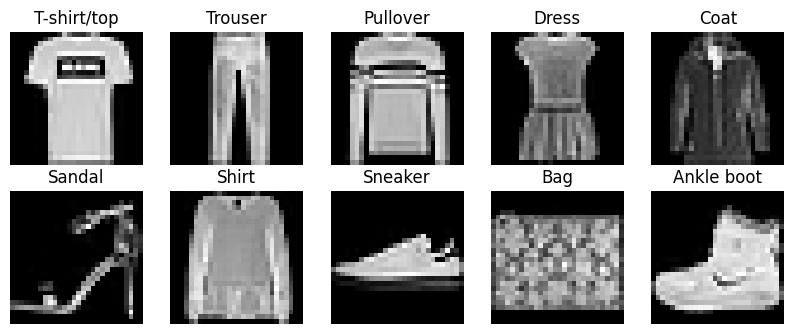

In [3]:
plt.figure(figsize=(10,10))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')
plt.show()

# Normalize

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN

In [5]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

**PART 2: SHALLOW CNN**

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build shallow CNN

In [7]:
shallow_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

shallow_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Train

In [8]:
history_shallow = shallow_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8447 - loss: 0.4408 - val_accuracy: 0.8791 - val_loss: 0.3396
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.8921 - loss: 0.2987 - val_accuracy: 0.8982 - val_loss: 0.2881
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.9083 - loss: 0.2520 - val_accuracy: 0.8984 - val_loss: 0.2795
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.9194 - loss: 0.2216 - val_accuracy: 0.9093 - val_loss: 0.2600
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9268 - loss: 0.1968 - val_accuracy: 0.9062 - val_loss: 0.2548
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9370 - loss: 0.1725 - val_accuracy: 0.9142 - val_loss: 0.2465
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9431 - loss: 0.1530 - val_accuracy: 0.9127 - val_loss: 0.2567
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9493 -

# Evaluate

In [9]:
test_loss_shallow, test_acc_shallow = shallow_model.evaluate(x_test, y_test)
print("Shallow CNN Test Accuracy:", test_acc_shallow)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9117 - loss: 0.2960
Shallow CNN Test Accuracy: 0.9117000102996826


# Plot

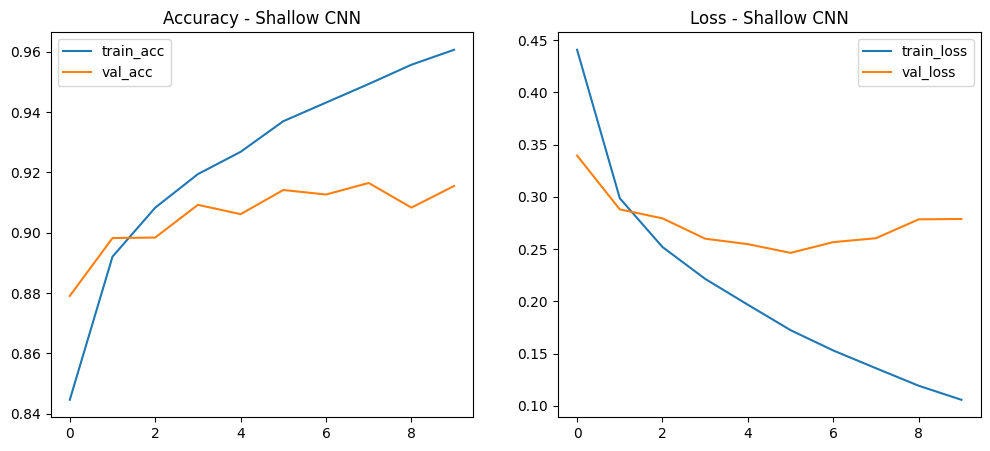

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_shallow.history['accuracy'], label='train_acc')
plt.plot(history_shallow.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy - Shallow CNN")

plt.subplot(1,2,2)
plt.plot(history_shallow.history['loss'], label='train_loss')
plt.plot(history_shallow.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss - Shallow CNN")

plt.show()

**PART 3: DEEP CNN**

In [13]:
deep_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

deep_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Train

In [16]:
history_deep = deep_model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 166s 111ms/step - accuracy: 0.9886 - loss: 0.0326 - val_accuracy: 0.9211 - val_loss: 0.4429
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 193s 129ms/step - accuracy: 0.9889 - loss: 0.0316 - val_accuracy: 0.9269 - val_loss: 0.4301
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 156s 104ms/step - accuracy: 0.9916 - loss: 0.0246 - val_accuracy: 0.9219 - val_loss: 0.4841
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 201s 103ms/step - accuracy: 0.9915 - loss: 0.0257 - val_accuracy: 0.9147 - val_loss: 0.5673
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 203s 104ms/step - accuracy: 0.9903 - loss: 0.0283 - val_accuracy: 0.9193 - val_loss: 0.5266
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 201s 104ms/step - accuracy: 0.9935 - loss: 0.0191 - val_accuracy: 0.9197 - val_loss: 0.5733
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 155s 103ms/step - accuracy: 0.9917 - loss: 0.0250 - val_accuracy: 0.9216 - val_loss: 0.5368
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 155s 104ms/step - ac

# Evaluate

In [18]:
test_loss_deep, test_acc_deep = deep_model.evaluate(x_test, y_test)
print("Deep CNN Test Accuracy:", test_acc_deep)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9135 - loss: 0.6561
Deep CNN Test Accuracy: 0.9135000109672546


# Plot

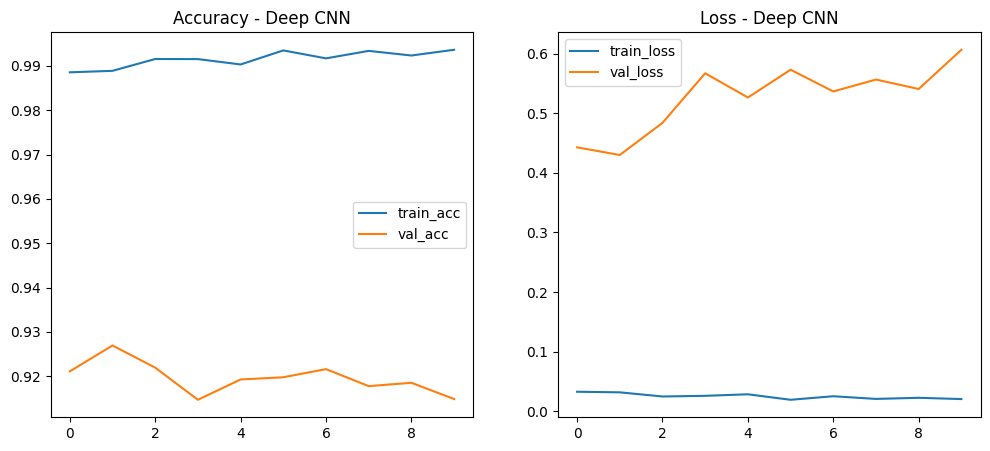

In [19]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_deep.history['accuracy'], label='train_acc')
plt.plot(history_deep.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy - Deep CNN")

plt.subplot(1,2,2)
plt.plot(history_deep.history['loss'], label='train_loss')
plt.plot(history_deep.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss - Deep CNN")

plt.show()

**PART 4: COMPARISON TABLE**

In [20]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "Conv Layers",
        "Total Parameters",
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy"
    ],
    "Shallow CNN": [
        1,
        shallow_model.count_params(),
        history_shallow.history['accuracy'][-1],
        history_shallow.history['val_accuracy'][-1],
        test_acc_shallow
    ],
    "Deep CNN": [
        3,
        deep_model.count_params(),
        history_deep.history['accuracy'][-1],
        history_deep.history['val_accuracy'][-1],
        test_acc_deep
    ]
})

print(comparison)

                Metric    Shallow CNN       Deep CNN
0          Conv Layers       1.000000       3.000000
1     Total Parameters  347146.000000  503690.000000
2    Training Accuracy       0.960625       0.993646
3  Validation Accuracy       0.915500       0.914833
4        Test Accuracy       0.911700       0.913500


** PART 5: PREDICTION & ERROR ANALYSIS**

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions

In [22]:
y_pred_shallow = np.argmax(shallow_model.predict(x_test), axis=1)
y_pred_deep = np.argmax(deep_model.predict(x_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step


# Function to display images

In [24]:
def display_images(images, labels_true, labels_pred, title):
    plt.figure(figsize=(10,5))
    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(images[i].reshape(28,28), cmap='gray')
        plt.title(f"T:{class_names[labels_true[i]]}\nP:{class_names[labels_pred[i]]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Correct predictions

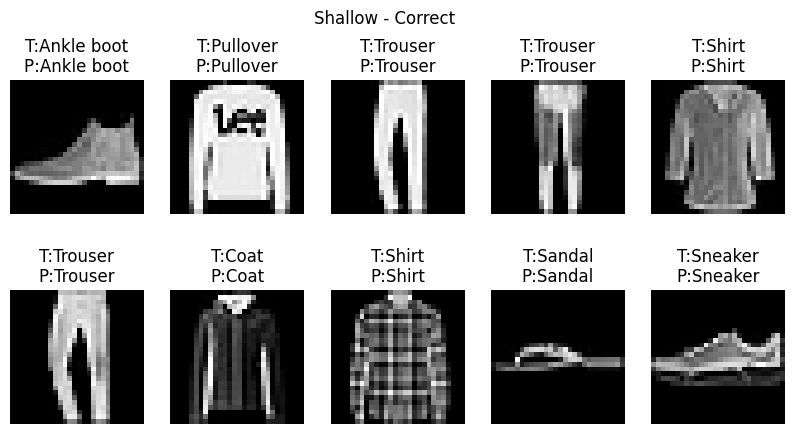

In [25]:
correct_idx = np.where(y_pred_shallow == y_test)[0][:10]
display_images(x_test[correct_idx], y_test[correct_idx], y_pred_shallow[correct_idx], "Shallow - Correct")

# Incorrect predictions

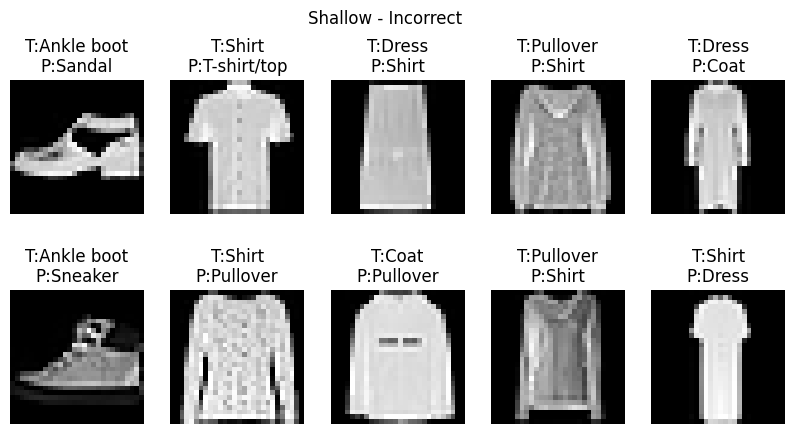

In [26]:
incorrect_idx = np.where(y_pred_shallow != y_test)[0][:10]
display_images(x_test[incorrect_idx], y_test[incorrect_idx], y_pred_shallow[incorrect_idx], "Shallow - Incorrect")

# Confusion Matrix - Shallow

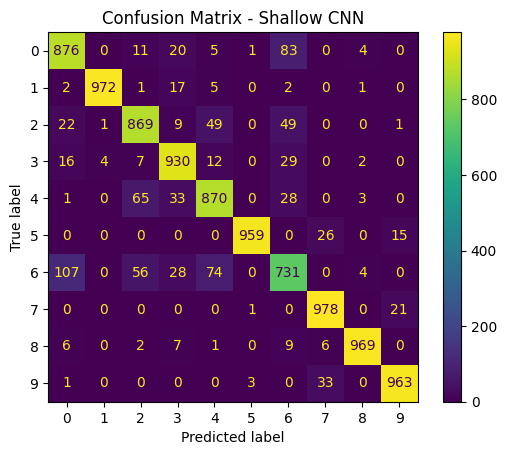

In [27]:
cm_shallow = confusion_matrix(y_test, y_pred_shallow)
ConfusionMatrixDisplay(cm_shallow).plot()
plt.title("Confusion Matrix - Shallow CNN")
plt.show()

# Deep CNN correct

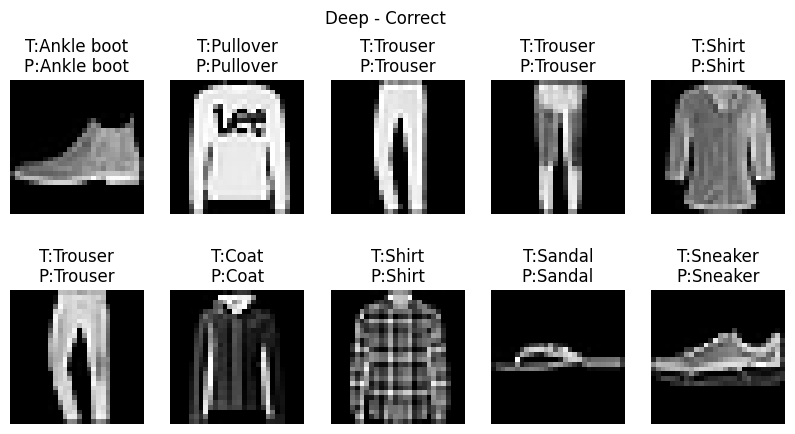

In [28]:
correct_idx = np.where(y_pred_deep == y_test)[0][:10]
display_images(x_test[correct_idx], y_test[correct_idx], y_pred_deep[correct_idx], "Deep - Correct")

#Deep CNN incorrect


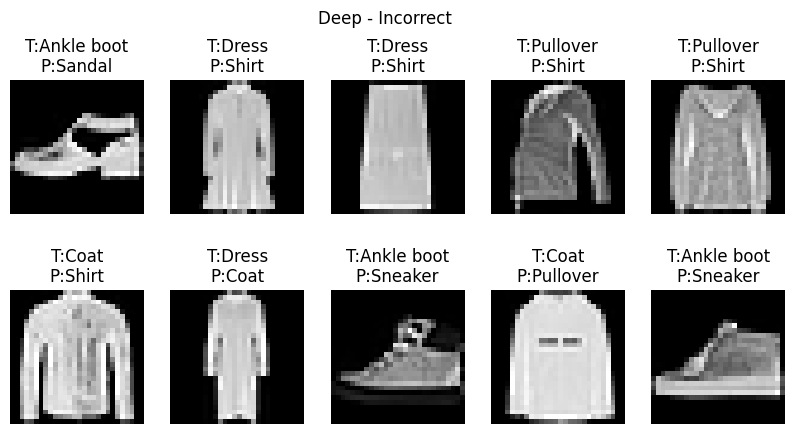

In [29]:
incorrect_idx = np.where(y_pred_deep != y_test)[0][:10]
display_images(x_test[incorrect_idx], y_test[incorrect_idx], y_pred_deep[incorrect_idx], "Deep - Incorrect")



# Confusion Matrix - Deep

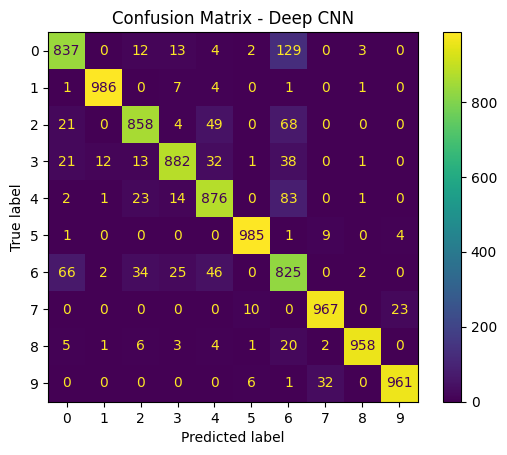

In [30]:
cm_deep = confusion_matrix(y_test, y_pred_deep)
ConfusionMatrixDisplay(cm_deep).plot()
plt.title("Confusion Matrix - Deep CNN")
plt.show()